# TENSORS

In [1]:
import torch
import numpy as np

In [2]:
data = [[1,2],[3,4]]
x_data = torch.tensor(data)

In [3]:
x_data

tensor([[1, 2],
        [3, 4]])

In [4]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [5]:
x_np

tensor([[1, 2],
        [3, 4]])

In [6]:
x_ones = torch.ones_like(x_data)
print(x_ones)

tensor([[1, 1],
        [1, 1]])


In [7]:
x_rand = torch.rand_like(x_data, dtype=torch.float) # overriding the dtype of x_data
print(x_rand)

tensor([[0.6650, 0.4836],
        [0.9831, 0.4036]])


In [8]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f'Rand Tesnor: \n{rand_tensor}')
print(f'Ones Tensor: \n{ones_tensor}')
print(f'Zeros Tensor: \n{zeros_tensor}')

Rand Tesnor: 
tensor([[0.5965, 0.2685, 0.2998],
        [0.3035, 0.9191, 0.1675]])
Ones Tensor: 
tensor([[1., 1., 1.],
        [1., 1., 1.]])
Zeros Tensor: 
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [9]:
tensor = torch.rand(3,4)

print(f"Shape: {tensor.shape}")
print(f"Datatype: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape: torch.Size([3, 4])
Datatype: torch.float32
Device tensor is stored on: cpu


In [10]:
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [11]:
tensor = tensor.to(device)
print(f'Device tensor is stored on: {tensor.device}')

Device tensor is stored on: cuda:0


In [12]:
tensor = torch.ones(4,4)
tensor

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [13]:
tensor[:,1] = 0
tensor

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [14]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
t1

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])

In [15]:
t2 = torch.cat([tensor, tensor, tensor], dim=0)
t2

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [16]:
tensor.mul(tensor)  # element wise multiplication

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [17]:
tensor*tensor     # element wise multiplication

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [18]:
tensor.matmul(tensor)  # matrix multiplication

tensor([[3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.]])

In [19]:
tensor @ tensor.T  # matrix multiplication

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

In [20]:
tensor

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [21]:
print(f'{tensor.add(4)}\n')
print(f'Original tensor: \n{tensor}')

tensor([[5., 4., 5., 5.],
        [5., 4., 5., 5.],
        [5., 4., 5., 5.],
        [5., 4., 5., 5.]])

Original tensor: 
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [22]:
# operations with _ suffix are in-place.

print(f'{tensor.add_(5)}\n')
print(f'Original tensor: \n{tensor}')

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])

Original tensor: 
tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


In [23]:
t = torch.ones(5)
print(f't: {t}')
n = t.numpy()
print(f't: {t}')

t: tensor([1., 1., 1., 1., 1.])
t: tensor([1., 1., 1., 1., 1.])


In [24]:
# Tensors on the CPU and numpy arrays CAN share their underlying memory locations, and hence changing the content of one will get reflected in the other one

In [25]:
t.add_(1)      # change in the torch tensor will get reflected in the numpy array
print(f't: {t}')
print(f'n: {n}')

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [26]:
n = np.ones(5)
t = torch.from_numpy(n)

In [27]:
np.add(n, 1, out=n)  # change in the numpy array will get reflected in the torch tensor
print(f't: {t}')
print(f'n: {n}')

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


# An Introduction to TORCH.AUTOGRAD

## Usage in PyTorch

In [28]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.6MB/s]


In [29]:
prediction = model(data)

In [30]:
loss = (prediction - labels).sum()
loss.backward()

In [31]:
optim = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [32]:
optim.step()

## Differentiation in AutoGrad

In [33]:
a = torch.tensor([2.,3.], requires_grad=True)
b = torch.tensor([6.,4.], requires_grad=True)

In [34]:
Q = 3*a**3 - b**2

In [35]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient = external_grad)

In [36]:
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


In [37]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f'Does `a` requires gradients? : {a.requires_grad}')
b = x + z
print(f'Does `b` requires gradients? : {b.requires_grad}')

Does `a` requires gradients? : False
Does `b` requires gradients? : True


In [38]:
from torch import nn, optim

model = resnet18(weights = ResNet18_Weights.DEFAULT)

# Freezing all the parameters in the network
for param in model.parameters():
  param.requires_grad = False

In [39]:
model.fc = nn.Linear(512, 10)

In [40]:
# Optimize only the classifier (last layer)
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Even though we are passing the whole params of the model, only the params(weights and bias) of the classifier will get updated by gradient descent.

# Neural Networks

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 5)
    self.conv2 = nn.Conv2d(6, 16, 5)

    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, input):

    c1 = F.relu(self.conv1(input))  # c1 = (N, 6, 28, 28)
    s2 = F.max_pool2d(c1, (2,2))    # s2 = (N, 6, 14, 14)
    c3 = F.relu(self.conv2(s2))     # c3 = (N, 16, 10, 10)
    s4 = F.max_pool2d(c3,2)         # s4 = (N, 16, 5, 5)
    s4 = torch.flatten(s4, 1)       # s4 = (N, 400)
    f5 = F.relu(self.fc1(s4))       # f5 = (N, 120)
    f6 = F.relu(self.fc2(f5))       # f6 = (N, 84)

    output = self.fc3(f6)           # output = (N, 10)
    return output

net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [42]:
params = list(net.parameters())
print(len(params))
print(params[0].size())

10
torch.Size([6, 1, 5, 5])


In [43]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)
print(f'Out shape: {out.shape}')

tensor([[-0.1303, -0.0561, -0.0225, -0.0505, -0.1044, -0.0203, -0.1444, -0.1412,
         -0.0904, -0.0785]], grad_fn=<AddmmBackward0>)
Out shape: torch.Size([1, 10])


In [44]:
net.zero_grad()
out.backward(torch.randn(1, 10))

In [45]:
output = net(input)
target = torch.randn(10)  # some dummy target
print(f'Before .view(1,-1) shape: {target.shape}')

target = target.view(1, -1)
print(f'After .view(1,-1) shape: {target.shape}')

criterion = nn.MSELoss()
loss = criterion(output, target)
print(loss)

Before .view(1,-1) shape: torch.Size([10])
After .view(1,-1) shape: torch.Size([1, 10])
tensor(0.5168, grad_fn=<MseLossBackward0>)


In [46]:
# Computation graph will be as follows:
'''
input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d -> Flatten -> linear -> relu -> linear -> relu -> linear -> MSELoss -> loss

'''

'\ninput -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d -> Flatten -> linear -> relu -> linear -> relu -> linear -> MSELoss -> loss\n\n'

In [47]:
print(loss.grad_fn)            # MSELoss
print(loss.grad_fn.next_functions[0][0])     # linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])   # relu

In [48]:
net.zero_grad()

print('conv1.bias.grad before backward: ')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward: ')
print(net.conv1.bias.grad)

conv1.bias.grad before backward: 
None
conv1.bias.grad after backward: 
tensor([ 0.0085, -0.0052,  0.0018,  0.0014,  0.0152,  0.0031])


In [49]:
import torch.optim as optim

optimizer = optim.SGD(net.parameters(), lr=0.01)

optimizer.zero_grad()
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()

# Training a Classifier

In [50]:
import torch
import torchvision
from torchvision.transforms import v2

In [51]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = transform
)

testset = torchvision.datasets.CIFAR10(
    root = './data',
    train = False,
    download = True,
    transform = transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 2
)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


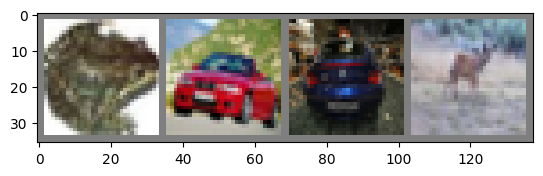

frog  car   car   deer 


In [52]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
  img = img/2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [58]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return x

net = Net()

In [59]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [60]:
for epoch in range(2):

  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data

    optimizer.zero_grad()

    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if i % 2000 == 1999:
      print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
      running_loss = 0.0

print("Training Finished")

[1,  2000] loss: 2.235
[1,  4000] loss: 1.739
[1,  6000] loss: 1.621
[1,  8000] loss: 1.576
[1, 10000] loss: 1.502
[1, 12000] loss: 1.450
[2,  2000] loss: 1.372
[2,  4000] loss: 1.385
[2,  6000] loss: 1.349
[2,  8000] loss: 1.300
[2, 10000] loss: 1.298
[2, 12000] loss: 1.282
Training Finished


In [62]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

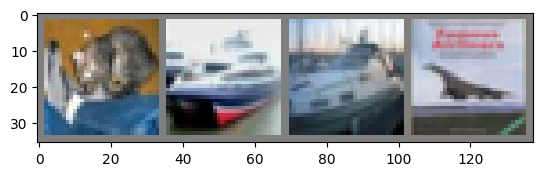

GroundTruth:  cat   ship  ship  plane


In [63]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [64]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [65]:
outputs = net(images)

In [66]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   car   ship  ship 


In [67]:
correct = 0
total = 0

with torch.no_grad():
  for data in testloader:
    images, labels = data

    outputs = net(images)

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


In [69]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
  for data in testloader:
    images, labels = data
    outputs = net(images)
    _, predictions = torch.max(outputs, 1)

    for label, prediction in zip(labels, predictions):
      if label == prediction:
        correct_pred[classes[label]] += 1
      total_pred[classes[label]] += 1


for classname, correct_count in correct_pred.items():
  accuracy = 100 * float(correct_count) / total_pred[classname]
  print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 50.0 %
Accuracy for class: car   is 67.8 %
Accuracy for class: bird  is 24.4 %
Accuracy for class: cat   is 19.5 %
Accuracy for class: deer  is 37.1 %
Accuracy for class: dog   is 72.8 %
Accuracy for class: frog  is 70.7 %
Accuracy for class: horse is 52.6 %
Accuracy for class: ship  is 69.5 %
Accuracy for class: truck is 75.5 %


## Training on GPU

In [70]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


In [71]:
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [72]:
inputs, labels = data[0].to(device), data[1].to(device)